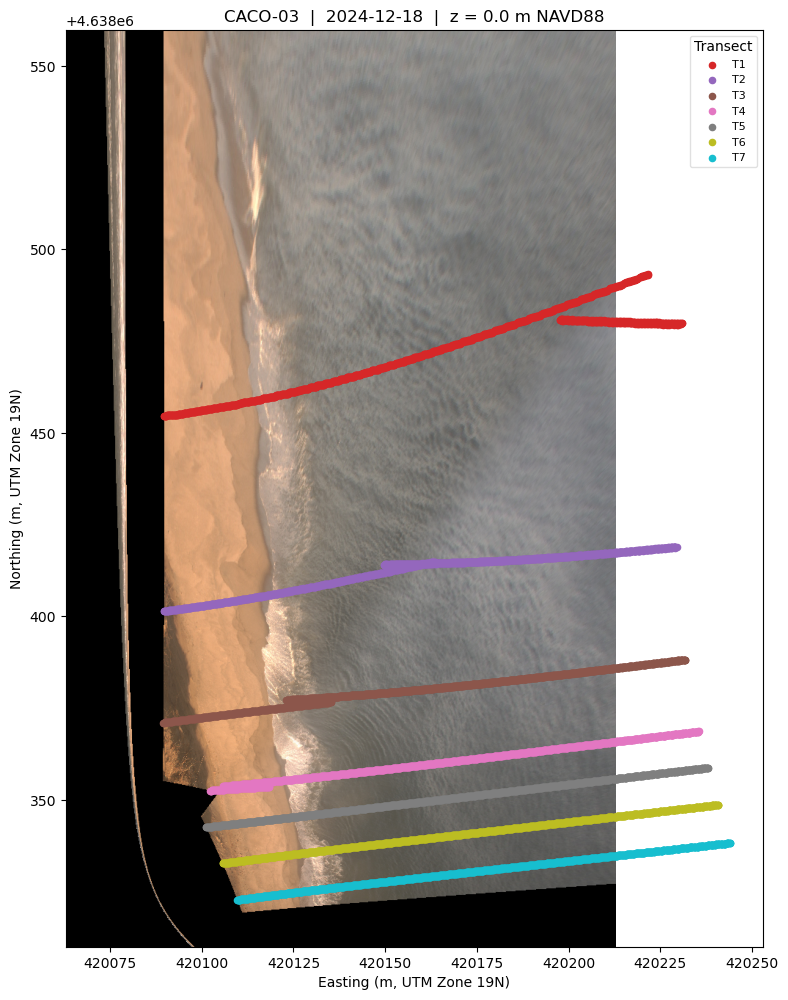

In [1]:
# csherwood@usgs.gov, 2026-06-12, generated with Claude Sonnet 4.6
import numpy as np
import matplotlib.pyplot as plt
import yaml
import rioxarray
from PIL import Image

# ── utils_CIRN functions ───────────────────────────────────────────────────────
%run -i F:\crs\src\ShoreScan\runup\CODES\utils_CIRN.py

# ── Configuration ─────────────────────────────────────────────────────────────
CAL_DIR  = r"F:\crs\proj\marconi_imagery\calibration_parameters"
PIX_DIR  = r"F:\crs\proj\marconi_imagery\pixel_locations"
DEM_PATH = r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2024_Oct_Marconi_DSM_camera_5cm_cog.tif"

IO_C1 = CAL_DIR + r"\CACO03_c1_20240801_IO.yaml"
IO_C2 = CAL_DIR + r"\CACO03_c2_20240801_IO.yaml"
EO_C1 = CAL_DIR + r"\CACO03_c1_20241023_EO.yaml"
EO_C2 = CAL_DIR + r"\CACO03_c2_20241023_EO.yaml"

C1_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c1\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c1.snap.jpg"
C2_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c2\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c2.snap.jpg"
C1_PIX = PIX_DIR + r"\c1_timestack.pix"
C2_PIX = PIX_DIR + r"\c2_timestack.pix"

GRID_RES   = 0.2
CAM_X      = 420088.0
CAM_Y      = 4638320.0
x_min, x_max = CAM_X - 25.0,  CAM_X + 125.0
y_min, y_max = CAM_Y - 10.0,  CAM_Y + 240.0

Z_PLANES      = [0.0, 1.0, 2.0]   # m NAVD88
Z_PLANE_PLOT  = 0.0                # which plane to show in rectified image

GAP_FACTOR  = 10.0
N_C2_START  = 3

# ── Load calibrations ─────────────────────────────────────────────────────────
def load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)

io1, io2 = load_yaml(IO_C1), load_yaml(IO_C2)
eo1, eo2 = load_yaml(EO_C1), load_yaml(EO_C2)

# ── Rectification grid (for image display at Z_PLANE_PLOT) ───────────────────
xs = np.arange(x_min, x_max, GRID_RES)
ys = np.arange(y_min, y_max, GRID_RES)
Xg, Yg = np.meshgrid(xs, ys)
Zg = np.full_like(Xg, Z_PLANE_PLOT)
xyz_grid = np.column_stack((Xg.ravel(), Yg.ravel(), Zg.ravel()))

def project_grid(xyz, io, eo):
    UVd, flag = xyz_to_dist_uv(io, eo, xyz)
    Ud = UVd[0].reshape(Xg.shape)
    Vd = UVd[1].reshape(Xg.shape)
    flag = flag.reshape(Xg.shape)
    valid = (flag == 1) & (Ud >= 0) & (Ud < io['NU']) & (Vd >= 0) & (Vd < io['NV'])
    Ud[~valid] = np.nan
    Vd[~valid] = np.nan
    return Ud, Vd

Ud1, Vd1 = project_grid(xyz_grid, io1, eo1)
Ud2, Vd2 = project_grid(xyz_grid, io2, eo2)

def sample_image(img_path, Ud, Vd):
    img = np.array(Image.open(img_path))
    h, w = img.shape[:2]
    Ir = np.zeros((*Ud.shape, 3), dtype=np.uint8)
    valid = ~np.isnan(Ud) & ~np.isnan(Vd)
    ui = np.where(valid, Ud, 0).astype(int).clip(0, w - 1)
    vi = np.where(valid, Vd, 0).astype(int).clip(0, h - 1)
    Ir[valid] = img[vi[valid], ui[valid]]
    return Ir, valid

Ir1, valid1 = sample_image(C1_IMG, Ud1, Vd1)
Ir2, valid2 = sample_image(C2_IMG, Ud2, Vd2)
IrIndv = np.stack([Ir1, Ir2], axis=-1).astype(float)
Ir_merged = camera_seam_blend(IrIndv)

# ── Transect detection ────────────────────────────────────────────────────────
def get_transect_ids(uv, gap_factor=GAP_FACTOR):
    dists = np.linalg.norm(np.diff(uv, axis=0), axis=1)
    threshold = np.median(dists) * gap_factor
    breaks = np.where(dists > threshold)[0] + 1
    ids = np.zeros(len(uv), dtype=int)
    for seg_id, start in enumerate(breaks):
        ids[start:] = seg_id + 1
    return ids

c1_uv = np.loadtxt(C1_PIX)
c2_uv = np.loadtxt(C2_PIX)
c1_ids = get_transect_ids(c1_uv)
c2_ids = get_transect_ids(c2_uv) + N_C2_START

def tab_color(i):
    return plt.colormaps['tab10'](i / 9)

# ── Project pixel transects to world coords at each Z_PLANE ──────────────────
# xyz_by_z[z] = {'c1': Nx3 array, 'c2': Nx3 array}
xyz_by_z = {}
for z in Z_PLANES:
    xyz_by_z[z] = {
        'c1': dist_uv_to_xyz(io1, eo1, c1_uv[:, 0], c1_uv[:, 1], 'z', z),
        'c2': dist_uv_to_xyz(io2, eo2, c2_uv[:, 0], c2_uv[:, 1], 'z', z),
    }

# convenience aliases for plotting and cell 2
c1_xyz = xyz_by_z[Z_PLANE_PLOT]['c1']
c2_xyz = xyz_by_z[Z_PLANE_PLOT]['c2']

# ── Plot rectified image with Z_PLANE_PLOT transects ─────────────────────────
extent = [xs[0], xs[-1], ys[0], ys[-1]]

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(Ir_merged, origin='lower', extent=extent, aspect='equal')

for (xyz, ids), label in zip([(c1_xyz, c1_ids), (c2_xyz, c2_ids)], ['c1', 'c2']):
    for tid in np.unique(ids):
        mask = ids == tid
        cstart = 0 if label == 'c2' else 3
        ax.scatter(xyz[mask, 0], xyz[mask, 1],
                   color=tab_color(tid + cstart), s=20, zorder=5,
                   label=f'T{tid + 1}' if label == 'c1' else None)

ax.set_xlabel('Easting (m, UTM Zone 19N)')
ax.set_ylabel('Northing (m, UTM Zone 19N)')
ax.set_title(f'CACO-03  |  2024-12-18  |  z = {Z_PLANE_PLOT} m NAVD88')
ax.legend(loc='upper right', fontsize=8, framealpha=0.6, title='Transect')
plt.tight_layout()
plt.savefig('rectified_merged_transects.png', dpi=150, bbox_inches='tight')
plt.show()

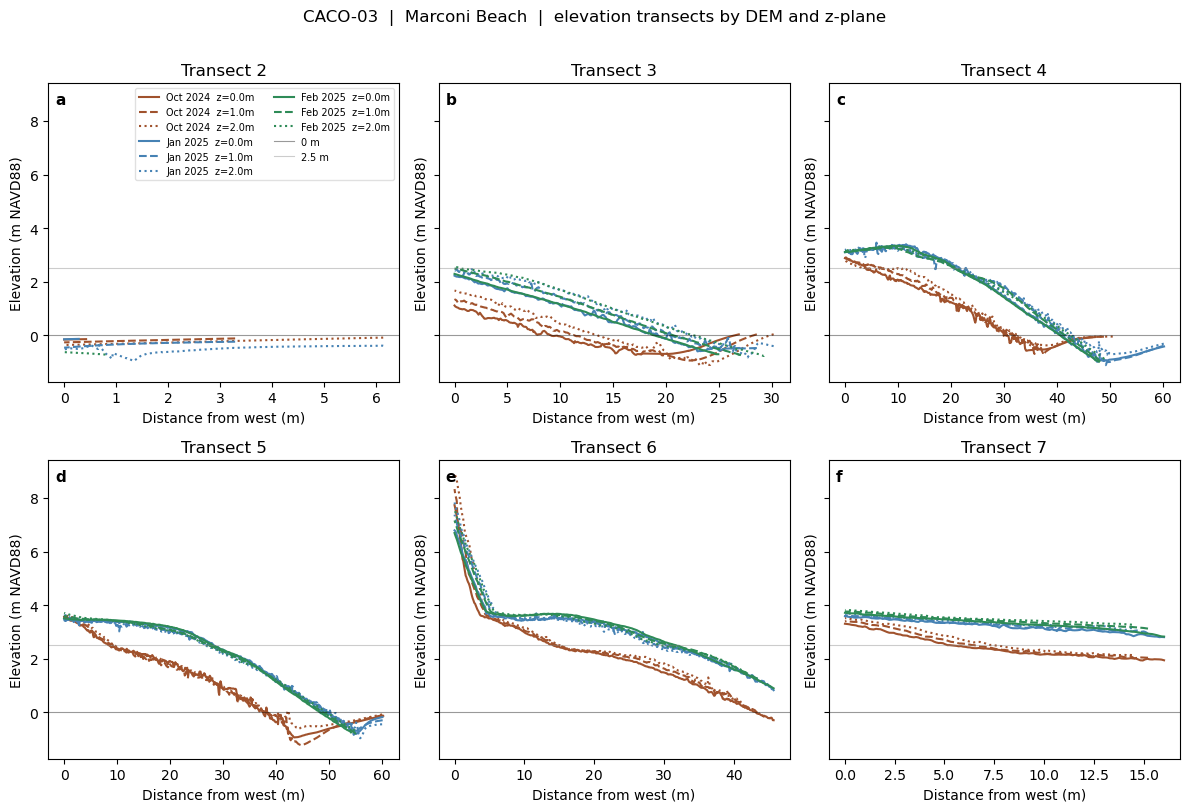

In [2]:
# csherwood@usgs.gov, 2026-06-12, generated with Claude Sonnet 4.6
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
from scipy.interpolate import RegularGridInterpolator

# ── DEM list ──────────────────────────────────────────────────────────────────
DEM_file_list = [
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2024_Oct_Marconi_DSM_camera_5cm_cog.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2025_Jan_Marconi_DSM_camera_5cm_interp_cog.tif",
    r"F:\crs\proj\2025_Marconi_maps\Marconi_Products\2025-005-FA_Marconi_Jan_YSMP_DSM_25cm.tif",
]
DEM_file_names = ['Oct 2024', 'Jan 2025', 'Feb 2025']
DEM_colors     = ['sienna', 'steelblue', 'seagreen']

EASTING_MAX = 420150.0

# ── Build DEM interpolators ───────────────────────────────────────────────────
def build_interp(path):
    dem = rioxarray.open_rasterio(path, masked=True).squeeze()
    x = dem.x.values
    y = dem.y.values
    z = dem.values
    if y[0] > y[-1]:
        y, z = y[::-1], z[::-1, :]
    return RegularGridInterpolator((y, x), z, method='linear',
                                   bounds_error=False, fill_value=np.nan)

interp_list = [build_interp(p) for p in DEM_file_list]

# ── Sample one DEM + one z-plane along all transects ─────────────────────────
def sample_transects(xyz_c1, xyz_c2, interp):
    transects = {}
    for xyz, ids in [(xyz_c1, c1_ids), (xyz_c2, c2_ids)]:
        for tid in np.unique(ids):
            mask = (ids == tid) & (xyz[:, 0] <= EASTING_MAX)
            if mask.sum() < 2:
                continue
            pts  = xyz[mask]
            elev = interp((pts[:, 1], pts[:, 0]))
            dist = pts[:, 0] - pts[:, 0].min()
            transects[tid] = {'dist': dist, 'elev': elev}
    return transects

# ── Build results: results[z_plane][dem_name] = transect dict ────────────────
# 6 combinations: 3 DEMs x 3 z-planes
results = {}
for z in Z_PLANES:
    xyz_c1 = xyz_by_z[z]['c1']
    xyz_c2 = xyz_by_z[z]['c2']
    results[z] = {
        name: sample_transects(xyz_c1, xyz_c2, interp)
        for name, interp in zip(DEM_file_names, interp_list)
    }

all_tids = sorted(set().union(*[
    d.keys()
    for z_dict in results.values()
    for d in z_dict.values()
]))
N_TRANSECTS = len(all_tids)

# line styles for z-planes, colors for DEMs (same as before)
Z_STYLES = {0.0: '-', 1.0: '--', 2.0: ':'}

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols = 3
nrows = int(np.ceil(N_TRANSECTS / ncols))
panel_labels = 'abcdefg'

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharey=True)
axes = axes.ravel()

for idx, tid in enumerate(all_tids):
    ax = axes[idx]

    for dcolor, name in zip(DEM_colors, DEM_file_names):
        for z in Z_PLANES:
            tdict = results[z][name]
            if tid not in tdict:
                continue
            dist = tdict[tid]['dist']
            elev = tdict[tid]['elev']
            lbl  = f'{name}  z={z}m' if idx == 0 else None
            ax.plot(dist, elev, color=dcolor, ls=Z_STYLES[z], lw=1.5, label=lbl)

    ax.axhline(0,   color='k',    lw=0.8, ls='-',  alpha=0.4, label='0 m' if idx == 0 else None)
    ax.axhline(2.5, color='gray', lw=0.8, ls='-',  alpha=0.4, label='2.5 m' if idx == 0 else None)
    ax.set_xlabel('Distance from west (m)')
    ax.set_ylabel('Elevation (m NAVD88)')
    ax.set_title(f'Transect {tid + 1}')
    ax.text(0.02, 0.97, panel_labels[idx], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left')

axes[0].legend(fontsize=7, framealpha=0.6, ncol=2)

for ax in axes[N_TRANSECTS:]:
    ax.set_visible(False)

plt.suptitle('CACO-03  |  Marconi Beach  |  elevation transects by DEM and z-plane', y=1.01)
plt.tight_layout()
plt.savefig('dem_transect_profiles_multi.png', dpi=150, bbox_inches='tight')
plt.show()